# Bone Fracture Detection 



## SET-UP

### Check GPU

In [1]:
import torch
print('GPU available:', torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU name   :', torch.cuda.get_device_name(0))
    print('VRAM       :', round(torch.cuda.get_device_properties(0).total_memory/1e9, 1), 'GB')
else:
    print('⚠️  No GPU — go to Runtime → Change runtime type → T4 GPU')

GPU available: True
GPU name   : Tesla T4
VRAM       : 15.6 GB


In [ ]:
# Patch num_workers in all dataloader calls
import torch
# Colab T4 has 2 CPU cores — use 2 workers max
NUM_WORKERS = 2

print(f"CPU cores available: {torch.get_num_threads()}")
print(f"Setting num_workers = {NUM_WORKERS}")

CPU cores available: 1
Setting num_workers = 2


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### Install packages

In [4]:
!pip install -q timm==0.9.16 grad-cam==1.5.0 scikit-learn seaborn tqdm opencv-python
print('✅ Packages installed')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 60.0 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 96.1 MB/s eta 0:00:00
✅ Packages installed


### Set up project on  data dir

In [ ]:
import os, zipfile, shutil

# Single variable for Drive location
DRIVE_PATH = '/content/drive/MyDrive/My Works/Bone facture'

# Navigate to the Drive folder
os.chdir(DRIVE_PATH)
print('✅ Working directory:', os.getcwd())

# ── 1. Extract stage1.zip to data folder ─────────────
s1_zip = f'{DRIVE_PATH}/stage1.zip'
data_folder = f'{DRIVE_PATH}/data'

if os.path.exists(s1_zip):
    print('\n📦 Extracting stage1.zip to data folder... (may take 1-2 min)')
    with zipfile.ZipFile(s1_zip, 'r') as z:
        z.extractall(data_folder)
    print('✅ stage1.zip extracted to data/')
else:
    print('❌ stage1.zip NOT FOUND')

# ── 2. Extract stage2.zip to data folder ─────────────
s2_zip = f'{DRIVE_PATH}/stage2.zip'

if os.path.exists(s2_zip):
    print('\n📦 Extracting stage2.zip to data folder...')
    with zipfile.ZipFile(s2_zip, 'r') as z:
        z.extractall(data_folder)
    print('✅ stage2.zip extracted to data/')
else:
    print('❌ stage2.zip NOT FOUND')

# ── 3. Verify contents ─────────────────────────────
print('\n📁 Contents of data folder:')
if os.path.exists(data_folder):
    print(os.listdir(data_folder))
else:
    print('❌ data folder not found')

print('\n✅ All files extracted. Ready to use!')

✅ Working directory: /content/drive/MyDrive/My Works/Bone facture

📦 Extracting stage1.zip to data folder... (may take 1-2 min)
✅ stage1.zip extracted to data/

📦 Extracting stage2.zip to data folder...
✅ stage2.zip extracted to data/

📁 Contents of data folder:
['stage1', 'stage2']

✅ All files extracted. Ready to use!


### Verify dataset & src files

In [10]:
DRIVE_PATH = '/content/drive/MyDrive/My Works/Bone facture'

# Navigate to the Drive folder
os.chdir(DRIVE_PATH)
print('✅ Working directory:', os.getcwd())

print('\n📁 Contents of data folder:')
if os.path.exists(data_folder):
    print(os.listdir(data_folder))
else:
    print('❌ data folder not found')

✅ Working directory: /content/drive/MyDrive/My Works/Bone facture

📁 Contents of data folder:
['stage2', 'stage1']


In [11]:
import os

def count_images(folder):
    ext = {'.jpg', '.jpeg', '.png', '.bmp', '.tiff'}
    total = 0
    if not os.path.exists(folder):
        print(f'  ⚠️  MISSING: {folder}')
        return 0
    for root, dirs, files in os.walk(folder):
        dirs.sort()
        n = sum(1 for f in files if os.path.splitext(f)[1].lower() in ext)
        if n > 0:
            rel = os.path.relpath(root, '.')
            print(f'  {rel:<52} {n:>5} imgs')
            total += n
    return total

print('── Stage 1 data ──────────────────────────────────────')
t1 = count_images('data/stage1')
print(f'   TOTAL: {t1}\n')

print('── Stage 2 data ──────────────────────────────────────')
t2 = count_images('data/stage2')
print(f'   TOTAL: {t2}\n')

print('── src/ scripts ──────────────────────────────────────')
if os.path.exists('src'):
    for f in sorted(os.listdir('src')):
        print(f'  src/{f}')
else:
    print('  ❌ src/ folder missing!')

── Stage 1 data ──────────────────────────────────────
  data/stage1/test/fracture                             1193 imgs
  data/stage1/test/normal                                505 imgs
  data/stage1/train/fracture                            4851 imgs
  data/stage1/train/normal                              2417 imgs
  data/stage1/val/fracture                              1172 imgs
  data/stage1/val/normal                                 519 imgs
   TOTAL: 10657

── Stage 2 data ──────────────────────────────────────
  data/stage2/test/hairline                               17 imgs
  data/stage2/test/major_crack                            48 imgs
  data/stage2/train/hairline                             674 imgs
  data/stage2/train/major_crack                         1939 imgs
  data/stage2/val/hairline                                17 imgs
  data/stage2/val/major_crack                             48 imgs
   TOTAL: 2743

── src/ scripts ──────────────────────────────────────
  src/__py

## Model

### Preview sample X-rays

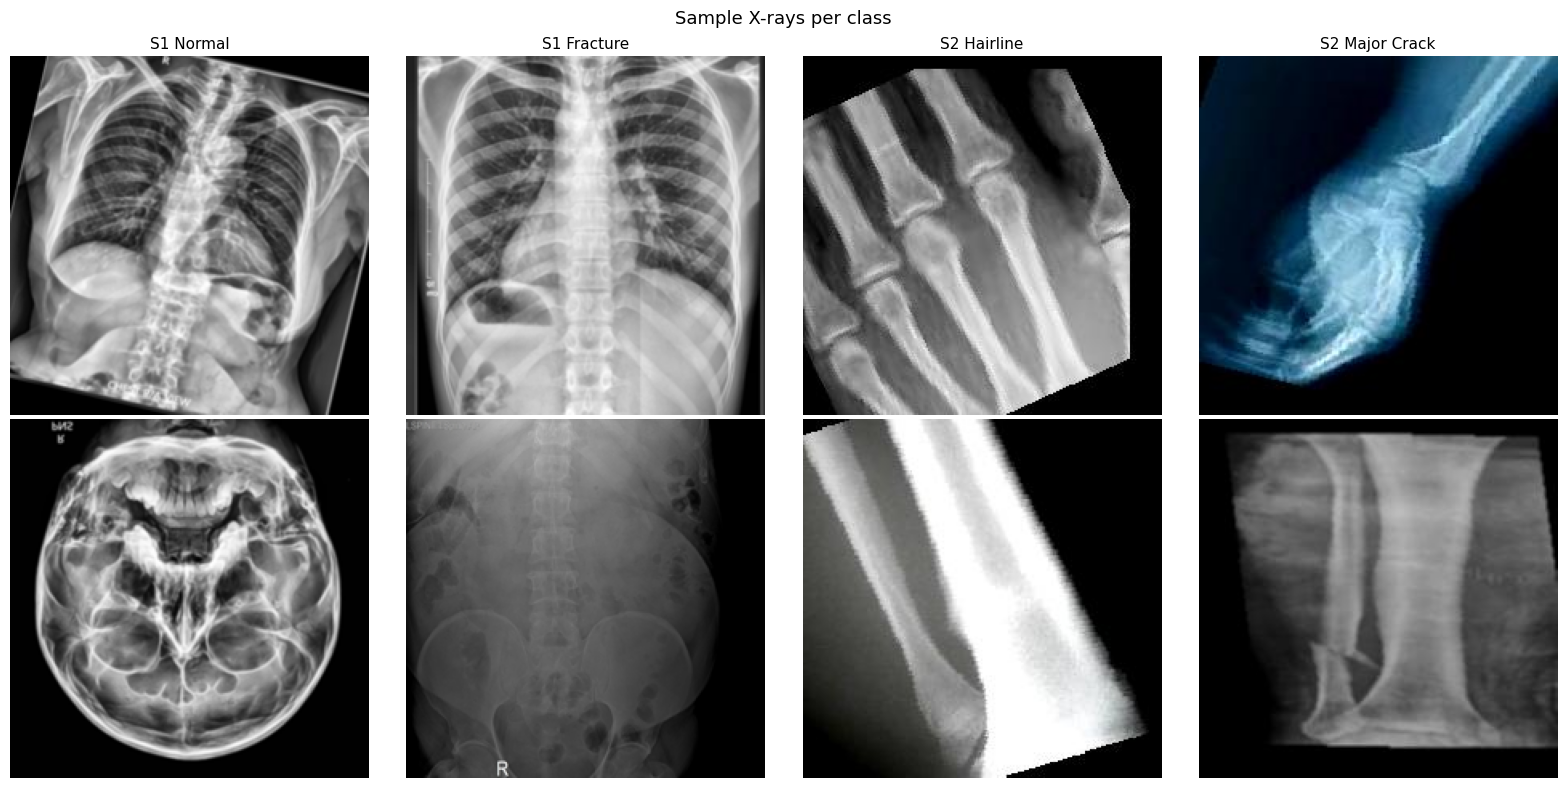

In [12]:
import matplotlib.pyplot as plt
from PIL import Image
import random, glob

classes = [
    ('data/stage1/train/normal',      'S1 Normal'),
    ('data/stage1/train/fracture',    'S1 Fracture'),
    ('data/stage2/train/hairline',    'S2 Hairline'),
    ('data/stage2/train/major_crack', 'S2 Major Crack'),
]
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for col, (folder, label) in enumerate(classes):
    imgs = glob.glob(f'{folder}/*.jpg') + glob.glob(f'{folder}/*.png') + glob.glob(f'{folder}/*.jpeg')
    for row in range(2):
        ax = axes[row][col]
        if imgs:
            img = Image.open(random.choice(imgs)).convert('RGB').resize((224,224))
            ax.imshow(img)
            if row == 0: ax.set_title(label, fontsize=11)
        else:
            ax.text(0.5, 0.5, f'No images\n{folder}', ha='center', va='center',
                    color='red', fontsize=8, transform=ax.transAxes)
        ax.axis('off')
plt.suptitle('Sample X-rays per class', fontsize=13)
plt.tight_layout()
plt.show()

### Train Stage 1 (Normal vs Fracture)

In [14]:
# Run train_stage1.py inline — shows all output + errors
import runpy, os, sys

# Make sure we're in project root and src is on path
os.chdir('/content/drive/MyDrive/My Works/Bone facture')
if 'src' not in sys.path: sys.path.insert(0, 'src')

print('Starting Stage 1 training...')
print('Working dir:', os.getcwd())
print('-' * 50)

try:
    runpy.run_path('src/train_stage1.py', run_name='__main__')
    print('\n✅ Stage 1 training complete!')
except SystemExit as e:
    if e.code == 0:
        print('\n✅ Stage 1 training complete!')
    else:
        print(f'\n❌ Stage 1 exited with code {e.code}')
except Exception as e:
    import traceback
    print('\n❌ Stage 1 ERROR:')
    traceback.print_exc()

Starting Stage 1 training...
Working dir: /content/drive/MyDrive/My Works/Bone facture
--------------------------------------------------

  Stage 1 Training — Normal vs Fracture
  Device: cuda

  Stage 1 | train |  7,268 images | classes: {'fracture': 0, 'normal': 1}
  Stage 1 | val   |  1,691 images | classes: {'fracture': 0, 'normal': 1}
  Stage 1 | test  |  1,698 images | classes: {'fracture': 0, 'normal': 1}
[Stage1 Model] EfficientNet-B4 | pretrained=True | freeze_backbone=True | trainable=13,109,818

Model loaded. Warming up head for 3 epochs...

Epoch 1/10 | Train Loss: 0.3352 Acc: 0.8733 | Val Loss: 0.4529 Acc: 0.8598 | LR: 0.001000 | 723.7s
  ✓ Best model saved (val_acc=0.8598)
Epoch 2/10 | Train Loss: 0.1916 Acc: 0.9253 | Val Loss: 0.5112 Acc: 0.8628 | LR: 0.001000 | 235.3s
  ✓ Best model saved (val_acc=0.8628)
Epoch 3/10 | Train Loss: 0.1745 Acc: 0.9316 | Val Loss: 0.5360 Acc: 0.8758 | LR: 0.001000 | 176.6s
  ✓ Best model saved (val_acc=0.8758)

→ Unfreezing full backbone a

### Train Stage 2 (Hairline / Major Crack)

In [15]:
import runpy, os, sys

os.chdir('/content/drive/MyDrive/My Works/Bone facture')
if 'src' not in sys.path: sys.path.insert(0, 'src')

print('Starting Stage 2 training...')
print('Working dir:', os.getcwd())
print('-' * 50)

try:
    runpy.run_path('src/train_stage2.py', run_name='__main__')
    print('\n✅ Stage 2 training complete!')
except SystemExit as e:
    if e.code == 0:
        print('\n✅ Stage 2 training complete!')
    else:
        print(f'\n❌ Stage 2 exited with code {e.code}')
except Exception as e:
    import traceback
    print('\n❌ Stage 2 ERROR:')
    traceback.print_exc()

Starting Stage 2 training...
Working dir: /content/drive/MyDrive/My Works/Bone facture
--------------------------------------------------

  Stage 2 Training — Hairline vs Major Crack
  Device: cuda
  Class counts: {'hairline': 77, 'major_crack': 709}

  Stage 2 | train |  2,613 images | classes: {'hairline': 0, 'major_crack': 1}
  Stage 2 | val   |     65 images | classes: {'hairline': 0, 'major_crack': 1}
  Stage 2 | test  |     65 images | classes: {'hairline': 0, 'major_crack': 1}
[FocalLoss] class order (sorted): ['hairline', 'major_crack']
[FocalLoss] alpha weights: {'hairline': 1.804071307182312, 'major_crack': 0.19592876732349396}


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 189MB/s]


[Stage2 Model] ResNet50 | trainable=525,058 | device=cpu

Model loaded. Warming up head for 5 epochs...



/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


Epoch 001/60 | Train Loss: 0.0354 F1: 0.3358 | Val Loss: 0.0290 F1: 0.2073 Acc: 0.2615 | 107.0s
    hairline             F1 = 0.4146
    major_crack          F1 = 0.0000
  ✓ Best model saved (macro_f1=0.2073)
Epoch 002/60 | Train Loss: 0.0273 F1: 0.3383 | Val Loss: 0.0250 F1: 0.2073 Acc: 0.2615 | 59.0s
    hairline             F1 = 0.4146
    major_crack          F1 = 0.0000
Epoch 003/60 | Train Loss: 0.0267 F1: 0.3326 | Val Loss: 0.0229 F1: 0.2073 Acc: 0.2615 | 44.0s
    hairline             F1 = 0.4146
    major_crack          F1 = 0.0000
Epoch 004/60 | Train Loss: 0.0266 F1: 0.3298 | Val Loss: 0.0249 F1: 0.2073 Acc: 0.2615 | 30.2s
    hairline             F1 = 0.4146
    major_crack          F1 = 0.0000
Epoch 005/60 | Train Loss: 0.0256 F1: 0.3332 | Val Loss: 0.0262 F1: 0.2073 Acc: 0.2615 | 29.4s
    hairline             F1 = 0.4146
    major_crack          F1 = 0.0000

→ Unfreezing full backbone at epoch 6

[Stage2 Model] All 24,033,090 params unfrozen
Epoch 006/60 | Train Loss: 0.

### Model Evaluation

In [16]:
import runpy, os, sys

os.chdir('/content/drive/MyDrive/My Works/Bone facture')
if 'src' not in sys.path: sys.path.insert(0, 'src')

print('Running evaluation...')
try:
    runpy.run_path('src/evaluate.py', run_name='__main__')
    print('\n✅ Evaluation complete!')
except SystemExit as e:
    if e.code == 0:
        print('\n✅ Evaluation complete!')
    else:
        print(f'\n❌ Evaluate exited with code {e.code}')
except Exception as e:
    import traceback
    print('\n❌ Evaluation ERROR:')
    traceback.print_exc()

Running evaluation...

  Evaluating Stage 1: Normal vs Fracture


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


  Stage 1 | train |  7,268 images | classes: {'fracture': 0, 'normal': 1}
  Stage 1 | val   |  1,691 images | classes: {'fracture': 0, 'normal': 1}
  Stage 1 | test  |  1,698 images | classes: {'fracture': 0, 'normal': 1}
[Stage1 Model] EfficientNet-B4 | pretrained=False | freeze_backbone=True | trainable=13,109,818
  Loaded checkpoint from epoch 7 (val_acc=0.8853)


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()



  Classification Report:
              precision    recall  f1-score   support

      normal     0.9141    0.8474    0.8795      1193
    fracture     0.6926    0.8119    0.7475       505

    accuracy                         0.8369      1698
   macro avg     0.8033    0.8297    0.8135      1698
weighted avg     0.8482    0.8369    0.8402      1698

  AUROC: 0.9195
  Confusion matrix saved → src/../results/confusion_matrix_stage1.png
  ROC curve saved → src/../results/roc_stage1.png

  Evaluating Stage 2: Hairline vs Major Crack
  Stage 2 | train |  2,613 images | classes: {'hairline': 0, 'major_crack': 1}
  Stage 2 | val   |     65 images | classes: {'hairline': 0, 'major_crack': 1}
  Stage 2 | test  |     65 images | classes: {'hairline': 0, 'major_crack': 1}


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


[Stage2 Model] ResNet50 | trainable=525,058 | device=cpu
  Loaded checkpoint from epoch 27 (val_f1=0.8300)


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()



  Classification Report:
              precision    recall  f1-score   support

    hairline     0.7059    0.7059    0.7059        17
 major_crack     0.8958    0.8958    0.8958        48

    accuracy                         0.8462        65
   macro avg     0.8009    0.8009    0.8009        65
weighted avg     0.8462    0.8462    0.8462        65

  Confusion matrix saved → src/../results/confusion_matrix_stage2.png
  ROC curve saved → src/../results/roc_stage2.png

All evaluation results saved to results/


✅ Evaluation complete!


## Testing  on a single image

In [20]:
import runpy, os, sys, glob

os.chdir('/content/drive/MyDrive/My Works/Bone facture')
if 'src' not in sys.path: sys.path.insert(0, 'src')

# ── Pick a test image automatically ───────────────────
test_imgs = (glob.glob('data/stage1/test/fracture/*.jpg') +
             glob.glob('data/stage1/test/fracture/*.png'))

if not test_imgs:
    print('No test images found in data/stage1/test/fracture/')
else:
    TEST_IMAGE = test_imgs[0]
    print('Testing on:', TEST_IMAGE)
    print('-' * 50)

    import sys as _sys
    _sys.argv = ['inference.py', '--image', TEST_IMAGE]

    try:
        runpy.run_path('src/inference.py', run_name='__main__')
    except SystemExit:
        pass
    except Exception as e:
        import traceback
        traceback.print_exc()

Testing on: data/stage1/test/fracture/1454_rt_foot_b_v_rt_foot_b_v_major_bony_lesion_1.png
--------------------------------------------------
[Stage1 Model] EfficientNet-B4 | pretrained=False | freeze_backbone=True | trainable=13,109,818
Stage 1 model loaded.
[Stage2 Model] ResNet50 | trainable=525,058 | device=cpu
Stage 2 model loaded.

─────────────────────────────────────────────
  Image       : 1454_rt_foot_b_v_rt_foot_b_v_major_bony_lesion_1.png
  Stage 1     : normal  (conf: 0.9999)
  ► FINAL     : NORMAL
─────────────────────────────────────────────

